# Imports

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data

In [2]:
appart_df = pd.read_csv('datasets_prepd/dvf_appartement.csv')
print(appart_df.head())

    id_mutation date_mutation  numero_disposition nature_mutation  \
0  2021-1289506    2021-01-08                   1           Vente   
1  2021-1289527    2021-01-11                   1           Vente   
2  2021-1289529    2021-01-04                   1           Vente   
3  2021-1289537    2021-01-06                   1           Vente   
4  2021-1289546    2021-01-04                   1           Vente   

   valeur_fonciere  adresse_numero adresse_suffixe  \
0         165000.0             1.0             NaN   
1         167000.0            11.0             NaN   
2         166000.0            51.0             NaN   
3         180000.0            66.0             NaN   
4         120000.0            50.0             NaN   

             adresse_nom_voie adresse_code_voie  code_postal  ...  \
0        RUE DU MOULIN A VENT              1570      77127.0  ...   
1  PL ANTOINE DE BOUGAINVILLE              0124      77380.0  ...   
2              RUE SOMMEVILLE              0960      

C:\Users\Amiral\AppData\Local\Temp\ipykernel_19980\2213143999.py:1: DtypeWarning: Columns (0: lot2_numero) have mixed types. Specify dtype option on import or set low_memory=False.
  appart_df = pd.read_csv('datasets_prepd/dvf_appartement.csv')


# Features

In [3]:
features = [
    "longitude",
    "latitude",
    "code_postal",
    "surface_reelle_bati",
    "nombre_pieces_principales",
    "total_carrez_surface",
    "number_of_lots",
    "season"
]

target = "valeur_fonciere_actualisee"

# Encode season to numeric values
season_mapping = {"winter": 0, "spring": 1, "summer": 2, "autumn": 3}
appart_df["season"] = appart_df["season"].map(season_mapping)

X = appart_df[features]
y = appart_df[target]

print("Feature count:", X.shape[1])
print(X.head())
print(y.head())

Feature count: 8
   longitude   latitude  code_postal  surface_reelle_bati  \
0   2.553326  48.628821      77127.0                 66.0   
1   2.569526  48.656643      77380.0                 67.0   
2        NaN        NaN      77380.0                 81.0   
3   2.562435  48.665468      77380.0                 60.0   
4   2.804714  48.376407      77250.0                 41.0   

   nombre_pieces_principales  total_carrez_surface  number_of_lots  season  
0                        3.0                 66.22             1.0       0  
1                        3.0                 67.40             1.0       0  
2                        4.0                 81.52             1.0       0  
3                        3.0                 60.06             1.0       0  
4                        2.0                 41.99             1.0       0  
0    165000.0
1    167000.0
2    166000.0
3    180000.0
4    120000.0
Name: valeur_fonciere_actualisee, dtype: float64


# Make sets : trail and test and validate

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (18620, 8)
Validation size: (3990, 8)
Test size: (3991, 8)


In [5]:
# Combine train + val for final model training
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
print("Train+Val size:", X_trainval.shape)  # ~85% des données

Train+Val size: (22610, 8)


# Ssave

In [6]:
os.makedirs("data_apt", exist_ok=True)

train_df = X_train.copy()
val_df = X_val.copy()
test_df = X_test.copy()

train_df[target] = y_train
val_df[target] = y_val
test_df[target] = y_test

train_df.to_csv("data_apt/appart_train.csv", index=False)
val_df.to_csv("data_apt/appart_val.csv", index=False)
test_df.to_csv("data_apt/appart_test.csv", index=False)

print("Datasets saved.")

Datasets saved.


# Train model

In [7]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

model.fit(X_trainval, y_trainval)
print("Modèle final entraîné sur Train+Val.")

Modèle final entraîné sur Train+Val.


# Feature importance

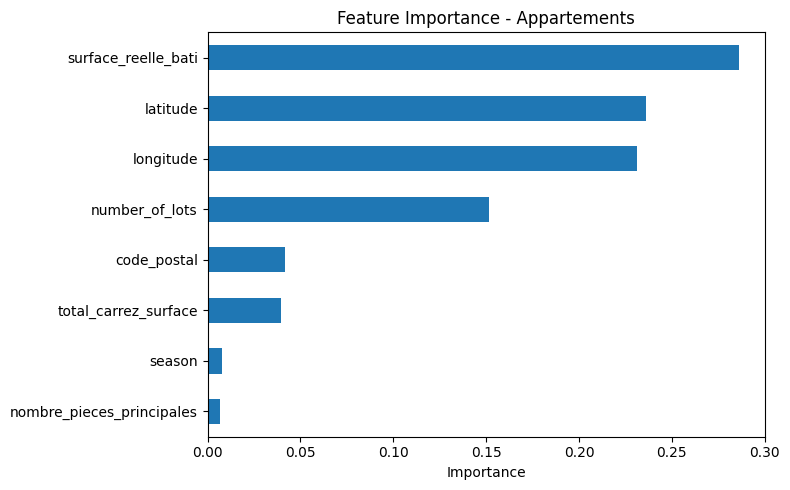


Feature importances:
  surface_reelle_bati: 0.2859
  latitude: 0.2360
  longitude: 0.2313
  number_of_lots: 0.1514
  code_postal: 0.0416
  total_carrez_surface: 0.0393
  season: 0.0078
  nombre_pieces_principales: 0.0066


In [8]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh')
plt.title("Feature Importance - Appartements")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nFeature importances:")
for name, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {name}: {imp:.4f}")

# Evaluation

In [9]:
for name, X_set, y_set in [("Train+Val", X_trainval, y_trainval), ("Test", X_test, y_test)]:
    y_pred = model.predict(X_set)
    rmse = np.sqrt(mean_squared_error(y_set, y_pred))
    mae = mean_absolute_error(y_set, y_pred)
    r2 = r2_score(y_set, y_pred)
    erreur_pct = (abs(y_set - y_pred) / y_set * 100).mean()
    print(f"{name:12s} — RMSE: {rmse:>10.0f} | MAE: {mae:>10.0f} | R2: {r2:.4f} | Erreur moy: {erreur_pct:.2f}%")

Train+Val    — RMSE:      32701 | MAE:      22485 | R2: 0.8292 | Erreur moy: 12.56%
Test         — RMSE:      39915 | MAE:      26781 | R2: 0.7586 | Erreur moy: 15.05%


# Comparaison GradientBoosting

In [10]:
gb = HistGradientBoostingRegressor(
    max_iter=300, max_depth=6, learning_rate=0.1,
    min_samples_leaf=10, random_state=42
)
gb.fit(X_trainval, y_trainval)

for name, X_set, y_set in [("Train+Val", X_trainval, y_trainval), ("Test", X_test, y_test)]:
    y_pred = gb.predict(X_set)
    r2 = r2_score(y_set, y_pred)
    erreur_pct = (abs(y_set - y_pred) / y_set * 100).mean()
    print(f"GB {name:12s} — R2: {r2:.4f} | Erreur moy: {erreur_pct:.2f}%")

GB Train+Val    — R2: 0.8240 | Erreur moy: 13.01%
GB Test         — R2: 0.7782 | Erreur moy: 14.48%


SAVE MODEL

In [11]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/apt_random_forest_model.pkl")

print("Model saved.")
print("Features sauvegardées:", list(model.feature_names_in_))

Model saved.
Features sauvegardées: ['longitude', 'latitude', 'code_postal', 'surface_reelle_bati', 'nombre_pieces_principales', 'total_carrez_surface', 'number_of_lots', 'season']
